In [8]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Generating training dataset

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

reviews_df = pd.read_csv("../data/interim/reviews_processed.csv")
sessions_df_clean = pd.read_csv("../data/interim/sessions_processed.csv")
listings_df = pd.read_csv("../data/interim/listings_processed.csv")

# Parse dates
reviews_df['date'] = pd.to_datetime(reviews_df['date'], errors='coerce')
reviews_df = reviews_df.dropna(subset=['date'])
sessions_df_clean['timestamp'] = pd.to_datetime(sessions_df_clean['timestamp'])

print(f"Reviews: {reviews_df.shape}")
print(f"Sessions: {sessions_df_clean.shape}")
print(f"Listings: {listings_df.shape}")

Reviews: (46935, 9)
Sessions: (470445, 4)
Listings: (4598, 8)


In [10]:
# Filter to relevant session types
sessions_filtered = sessions_df_clean[sessions_df_clean['action'].isin(['view_listing', 'book_listing'])].copy()
sessions_filtered = sessions_filtered.drop_duplicates()

# Separate views from bookings
views_df = sessions_filtered[sessions_filtered["action"] == "view_listing"][['user_id', 'timestamp', 'listing_id']].copy()
bookings_df = sessions_filtered[sessions_filtered["action"] == "book_listing"][['user_id', 'listing_id', 'timestamp']].copy()
bookings_df = bookings_df.rename(columns={'timestamp': 'booking_timestamp'})

# Forward point-in-time join: for each view, find if a booking happened within 24h
views_df = views_df.sort_values('timestamp')
bookings_df = bookings_df.sort_values('booking_timestamp')
merged_df = pd.merge_asof(
    left=views_df,
    right=bookings_df,
    left_on='timestamp',
    right_on='booking_timestamp',
    by=['user_id', 'listing_id'],
    direction='forward',
    tolerance=pd.Timedelta(hours=24)
)

# Y=1 if booking timestamp present (offer was reserved)
merged_df['Y'] = merged_df['booking_timestamp'].notna().astype(int)
training_data = merged_df.drop(columns=['booking_timestamp']).reset_index(drop=True)
print(f"Training data: {training_data.shape}")

Training data: (431281, 4)


In [11]:
print(len(training_data[training_data["Y"] == 1]))
print(len(training_data[training_data["Y"] == 0]))

15546
415735


## Feature engineering

For each training row (a user viewing a listing at time $T_0$), we compute review-based features looking **only at reviews posted before** $T_0$ (point-in-time correctness). Reviews become visible the day after posting (D+1 rule) to avoid data leakage.

**Generated features:**

| Feature | Description |
|---|---|
| `days_since_last_review` | Days between $T_0$ and the most recent visible review. -1 if listing has no reviews yet. |
| `reviews_in_last_90_days` | Count of reviews that became visible within 90 days before $T_0$. |
| `recent_review_scores_*` | Average VADER sentiment scores of reviews in the 90-day window (7 columns). |
| `alltime_review_count` | Total number of reviews visible at $T_0$. |
| `alltime_review_scores_*` | Average VADER sentiment scores across ALL visible reviews (7 columns). |

Then static listing attributes (price, bedrooms, etc.) are joined via **inner join** (only sessions with known listings are kept).

In [ ]:
sentiment_cols = [c for c in reviews_df.columns if c.startswith('review_scores_')]

# D+1 rule: a review posted on day D becomes visible on day D+1
reviews_df['visible_date'] = reviews_df['date'] + pd.Timedelta(days=1)

# FEATURE: days_since_last_review
# merge_asof backward: find the latest review visible BEFORE each session
td_sorted = training_data[['listing_id', 'timestamp']].copy()
td_sorted['_orig_idx'] = td_sorted.index
td_sorted = td_sorted.sort_values('timestamp')

rv_for_asof = reviews_df[['listing_id', 'visible_date', 'date']].sort_values('visible_date')

asof_result = pd.merge_asof(
    td_sorted,
    rv_for_asof.rename(columns={'visible_date': '_vis_ts', 'date': '_review_date'}),
    left_on='timestamp',
    right_on='_vis_ts',
    by='listing_id',
    direction='backward'
)
asof_result['days_since_last_review'] = (asof_result['timestamp'] - asof_result['_review_date']).dt.days

# NaN = listing has no reviews at all → fill with -1
training_data['days_since_last_review'] = (
    asof_result.set_index('_orig_idx')['days_since_last_review'].fillna(-1).astype(int)
)

pct_no_review = (training_data['days_since_last_review'] == -1).mean() * 100
print(f"days_since_last_review: {pct_no_review:.1f}% have no reviews (filled with -1)")
print(training_data['days_since_last_review'].describe())

,user_id,timestamp,listing_id,Y,days_since_last_review
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,NaN
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,NaN
2,162656,2009-11-18 02:16:11.925930,21316502,0,NaN
3,162656,2009-11-18 03:39:25.925930,976307,0,NaN
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,NaN


In [ ]:
# FEATURES: 90-day window + all-time historical features
td_slim = training_data[['listing_id', 'timestamp']].copy()
td_slim['_td_idx'] = td_slim.index

rv_slim = reviews_df[['listing_id', 'visible_date'] + sentiment_cols].copy()

print("Joining training rows with reviews...")
merged = td_slim.merge(rv_slim, on='listing_id', how='inner')

# Keep only reviews visible BEFORE the session
merged = merged[merged['visible_date'] <= merged['timestamp']]
merged['days_ago'] = (merged['timestamp'] - merged['visible_date']).dt.days
print(f"Total visible review-session pairs: {len(merged):,}")

# --- ALL-TIME features ---
alltime_agg = {col: 'mean' for col in sentiment_cols}
alltime_agg['visible_date'] = 'count'
alltime = merged.groupby('_td_idx').agg(alltime_agg)
alltime = alltime.rename(columns={'visible_date': 'alltime_review_count'})
alltime = alltime.rename(columns={c: f'alltime_{c}' for c in sentiment_cols})

# --- 90-DAY WINDOW features ---
recent = merged[merged['days_ago'] <= 90]
recent_agg = {col: 'mean' for col in sentiment_cols}
recent_agg['visible_date'] = 'count'
recent_feats = recent.groupby('_td_idx').agg(recent_agg)
recent_feats = recent_feats.rename(columns={'visible_date': 'reviews_in_last_90_days'})
recent_feats = recent_feats.rename(columns={c: f'recent_{c}' for c in sentiment_cols})

# Join all features back
training_data = training_data.join(alltime)
training_data = training_data.join(recent_feats)

# Fill NaN (sessions with no reviews at all)
training_data['alltime_review_count'] = training_data['alltime_review_count'].fillna(0).astype(int)
training_data['reviews_in_last_90_days'] = training_data['reviews_in_last_90_days'].fillna(0).astype(int)
for c in sentiment_cols:
    training_data[f'alltime_{c}'] = training_data[f'alltime_{c}'].fillna(0.0)
    training_data[f'recent_{c}'] = training_data[f'recent_{c}'].fillna(0.0)

pct_90d = (training_data['reviews_in_last_90_days'] > 0).mean() * 100
pct_all = (training_data['alltime_review_count'] > 0).mean() * 100
print(f"\nCoverage: {pct_90d:.1f}% have reviews in 90-day window, {pct_all:.1f}% have any review ever")
print(f"Features computed. Shape: {training_data.shape}")
training_data.head()

Computing 7-day review window features...
Review-session pairs in 7-day window: 4,179
Features computed. Shape: (431281, 13)


,user_id,timestamp,listing_id,Y,days_since_last_review,recent_review_scores_cleanliness,recent_review_scores_location,recent_review_scores_communication,recent_review_scores_checkin,recent_review_scores_value,recent_review_scores_accuracy,recent_review_scores_rating,reviews_in_last_7_days
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,162656,2009-11-18 02:16:11.925930,21316502,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,162656,2009-11-18 03:39:25.925930,976307,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0


In [ ]:
# Inner join: keep only sessions for listings we have data for
# (the listing table is a snapshot — old/removed listings are missing)
rows_before = len(training_data)
training_data['listing_id'] = training_data['listing_id'].astype('Int64')
listings_df['listing_id'] = listings_df['listing_id'].astype('Int64')
training_data = training_data.merge(listings_df, on='listing_id', how='inner')
print(f"Rows before join: {rows_before:,} → after inner join: {len(training_data):,} ({100*len(training_data)/rows_before:.1f}% kept)")

# Impute remaining nulls in numeric listing columns with median
num_cols = ['accommodates', 'bathrooms', 'bedrooms', 'price']
for col in num_cols:
    n_null = training_data[col].isnull().sum()
    if n_null > 0:
        training_data[col] = training_data[col].fillna(training_data[col].median())
        print(f"Imputed {n_null} nulls in {col} with median")

# Fill null categoricals with "Unknown"
cat_cols = ['property_type', 'room_type', 'neighbourhood_cleansed']
for col in cat_cols:
    training_data[col] = training_data[col].fillna('Unknown')

# One-hot encode (nominal categories, no natural order)
training_data = pd.get_dummies(training_data, columns=cat_cols, dtype=int)

print(f"\nFinal training data: {training_data.shape}")
print(f"Nulls remaining: {training_data.isnull().sum().sum()}")
print(f"\nColumn types:\n{training_data.dtypes}")
training_data.head()

Final training data: (431281, 66)

Column types:
user_id                                                      int64
timestamp                                           datetime64[us]
listing_id                                                   Int64
Y                                                            int64
days_since_last_review                                     float64
                                                         ...      
neighbourhood_cleansed_Nrrebro                               int64
neighbourhood_cleansed_Valby                                 int64
neighbourhood_cleansed_Vanlse                                int64
neighbourhood_cleansed_Vesterbro-Kongens Enghave             int64
neighbourhood_cleansed_sterbro                               int64
Length: 66, dtype: object


,user_id,timestamp,listing_id,Y,days_since_last_review,recent_review_scores_cleanliness,recent_review_scores_location,recent_review_scores_communication,recent_review_scores_checkin,recent_review_scores_value,...,neighbourhood_cleansed_Amager st,neighbourhood_cleansed_Bispebjerg,neighbourhood_cleansed_Brnshj-Husum,neighbourhood_cleansed_Frederiksberg,neighbourhood_cleansed_Indre By,neighbourhood_cleansed_Nrrebro,neighbourhood_cleansed_Valby,neighbourhood_cleansed_Vanlse,neighbourhood_cleansed_Vesterbro-Kongens Enghave,neighbourhood_cleansed_sterbro
0,153564,2009-09-13 11:40:28.184173,1388460895702079744,0,NaN,0.0,0.0,0.0,0.0,0.0,...,0,1,0,0,0,0,0,0,0,0
1,61037,2009-10-19 09:44:25.017236,909842584001911808,0,NaN,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
2,162656,2009-11-18 02:16:11.925930,21316502,0,NaN,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,1,0,0,0,0,0
3,162656,2009-11-18 03:39:25.925930,976307,0,NaN,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
4,162656,2009-11-18 04:17:51.925930,1330521203094184704,0,NaN,0.0,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0


## Class distribution

Class 0 (no booking): 415,735
Class 1 (booking):    15,546
Imbalance ratio Y=1/Y=0: 0.0374


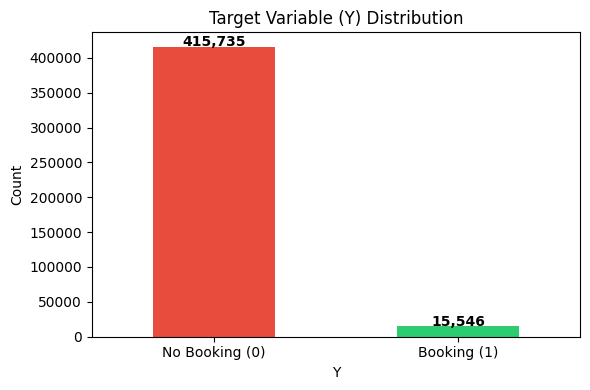

In [15]:
counts = training_data['Y'].value_counts().sort_index()
print(f"Class 0 (no booking): {counts.get(0, 0):,}")
print(f"Class 1 (booking):    {counts.get(1, 0):,}")
print(f"Imbalance ratio Y=1/Y=0: {counts.get(1, 0) / counts.get(0, 1):.4f}")

fig, ax = plt.subplots(figsize=(6, 4))
counts.plot(kind='bar', ax=ax, color=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['No Booking (0)', 'Booking (1)'], rotation=0)
ax.set_ylabel('Count')
ax.set_title('Target Variable (Y) Distribution')
for i, v in enumerate(counts):
    ax.text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## Generating inference sample

In [16]:
# Generate inference sample from the most recent 30 days of data
latest_date = training_data['timestamp'].max()
cutoff = latest_date - pd.Timedelta(days=30)

inference_sample = training_data[training_data['timestamp'] >= cutoff].copy()
inference_sample = inference_sample.drop(columns=['Y'])  # Target not available at inference time

print(f"Inference sample: {inference_sample.shape} (last 30 days of data)")
inference_sample.head()

Inference sample: (664, 65) (last 30 days of data)


,user_id,timestamp,listing_id,days_since_last_review,recent_review_scores_cleanliness,recent_review_scores_location,recent_review_scores_communication,recent_review_scores_checkin,recent_review_scores_value,recent_review_scores_accuracy,...,neighbourhood_cleansed_Amager st,neighbourhood_cleansed_Bispebjerg,neighbourhood_cleansed_Brnshj-Husum,neighbourhood_cleansed_Frederiksberg,neighbourhood_cleansed_Indre By,neighbourhood_cleansed_Nrrebro,neighbourhood_cleansed_Valby,neighbourhood_cleansed_Vanlse,neighbourhood_cleansed_Vesterbro-Kongens Enghave,neighbourhood_cleansed_sterbro
430617,40137464,2025-08-09 20:35:12.006548,955594135974379648,NaN,0.0,0.0000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,1,0
430618,360554333,2025-08-09 21:05:24.508420,1244147958257977344,NaN,0.0,0.0000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,1
430619,179697571,2025-08-09 21:25:27.516388,1397753249851294464,5.0,0.0,0.6654,0.0,0.0,0.0,0.0,...,0,0,0,0,0,1,0,0,0,0
430620,360554333,2025-08-09 21:46:06.508420,1502922937698947584,NaN,0.0,0.0000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0
430621,179697571,2025-08-09 22:20:52.516388,1434115704779021312,NaN,0.0,0.0000,0.0,0.0,0.0,0.0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
import os
os.makedirs("../data/processed", exist_ok=True)

training_data.to_csv("../data/processed/training_data.csv", index=False)
inference_sample.to_csv("../data/processed/inference_sample.csv", index=False)
print(f"Saved training_data.csv ({training_data.shape}) and inference_sample.csv ({inference_sample.shape}) to data/processed/")

OSError: Cannot save file into a non-existent directory: '..\data\processed'